In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchtext
from torchtext.datasets import Multi30k
from torchtext.data import Field, BucketIterator

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import stanza
import numpy as np
import random
import math
import time


In [2]:
SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True


In [3]:
import torch.serialization
import numpy.core.multiarray

torch.serialization.add_safe_globals([
    numpy.core.multiarray._reconstruct
])


In [4]:
import torch
print(torch.__version__)


2.5.1+cpu


In [5]:
stanza.download('en')
stanza.download('de')

spacy_en = stanza.Pipeline('en', processors='tokenize', tokenize_no_ssplit=True)
spacy_de = stanza.Pipeline('de', processors='tokenize', tokenize_no_ssplit=True)


2026-04-18 11:53:44 INFO: Downloading default packages for language: en (English) ...
2026-04-18 11:53:47 INFO: File exists: C:\Users\yathi\stanza_resources\en\default.zip
2026-04-18 11:53:54 INFO: Finished downloading models and saved to C:\Users\yathi\stanza_resources.


2026-04-18 11:53:54 INFO: Downloading default packages for language: de (German) ...
2026-04-18 11:53:56 INFO: File exists: C:\Users\yathi\stanza_resources\de\default.zip
2026-04-18 11:54:04 INFO: Finished downloading models and saved to C:\Users\yathi\stanza_resources.
2026-04-18 11:54:04 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-04-18 11:54:04 INFO: Loading these models for language: en (English):
| Processor | Package  |
------------------------
| tokenize  | combined |

2026-04-18 11:54:04 INFO: Using device: cpu
2026-04-18 11:54:04 INFO: Loading: tokenize
C:\Users\yathi\anaconda3\envs\pytorch\lib\site-packages\stanza\models\tokenization\trainer.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`

2026-04-18 11:54:09 WARNING: Language de package default expects mwt, which has been added
2026-04-18 11:54:09 INFO: Loading these models for language: de (German):
| Processor | Package |
-----------------------
| tokenize  | gsd     |
| mwt       | gsd     |

2026-04-18 11:54:09 INFO: Using device: cpu
2026-04-18 11:54:09 INFO: Loading: tokenize
C:\Users\yathi\anaconda3\envs\pytorch\lib\site-packages\stanza\models\tokenization\trainer.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loa

In [6]:
def tokenize_en(text):
    doc = spacy_en(text)
    return [w.text for s in doc.sentences for w in s.words]

def tokenize_de(text):
    doc = spacy_de(text)
    return [w.text for s in doc.sentences for w in s.words]


In [7]:
SRC = Field(
    tokenize=tokenize_en,
    init_token='<sos>',
    eos_token='<eos>',
    lower=True,
    batch_first=True
)

TRG = Field(
    tokenize=tokenize_de,
    init_token='<sos>',
    eos_token='<eos>',
    lower=True,
    batch_first=True
)


In [8]:
train_data, valid_data, test_data = Multi30k.splits(
    exts=('.en', '.de'),
    fields=(SRC, TRG),
    root='.data/'
)


In [9]:
SRC.build_vocab(train_data, min_freq=2)
TRG.build_vocab(train_data, min_freq=2)


In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)


Using device: cpu


In [11]:
BATCH_SIZE = 128

train_iterator, valid_iterator, test_iterator = BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size=BATCH_SIZE,
    device=device
)


In [12]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hid_dim, n_layers, n_heads, pf_dim, dropout, device, max_length=100):
        super().__init__()
        self.device = device
        self.tok_embedding = nn.Embedding(input_dim, hid_dim)
        self.pos_embedding = nn.Embedding(max_length, hid_dim)
        self.layers = nn.ModuleList([
            EncoderLayer(hid_dim, n_heads, pf_dim, dropout, device)
            for _ in range(n_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.scale = torch.sqrt(torch.FloatTensor([hid_dim])).to(device)

    def forward(self, src, src_mask):
        batch_size = src.shape[0]
        src_len = src.shape[1]
        pos = torch.arange(0, src_len).unsqueeze(0).repeat(batch_size, 1).to(self.device)
        src = self.dropout((self.tok_embedding(src) * self.scale) + self.pos_embedding(pos))
        for layer in self.layers:
            src = layer(src, src_mask)
        return src


In [13]:
class EncoderLayer(nn.Module):
    def __init__(self, hid_dim, n_heads, pf_dim, dropout, device):
        super().__init__()
        self.self_attn_layer_norm = nn.LayerNorm(hid_dim)
        self.ff_layer_norm = nn.LayerNorm(hid_dim)
        self.self_attention = MultiHeadAttentionLayer(hid_dim, n_heads, dropout, device)
        self.positionwise_feedforward = PositionwiseFeedforwardLayer(hid_dim, pf_dim, dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_mask):
        _src, _ = self.self_attention(src, src, src, src_mask)
        src = self.self_attn_layer_norm(src + self.dropout(_src))
        _src = self.positionwise_feedforward(src)
        src = self.ff_layer_norm(src + self.dropout(_src))
        return src


In [14]:
class MultiHeadAttentionLayer(nn.Module):
    def __init__(self, hid_dim, n_heads, dropout, device):
        super().__init__()
        assert hid_dim % n_heads == 0
        self.hid_dim = hid_dim
        self.n_heads = n_heads
        self.head_dim = hid_dim // n_heads
        self.fc_q = nn.Linear(hid_dim, hid_dim)
        self.fc_k = nn.Linear(hid_dim, hid_dim)
        self.fc_v = nn.Linear(hid_dim, hid_dim)
        self.fc_o = nn.Linear(hid_dim, hid_dim)
        self.dropout = nn.Dropout(dropout)
        self.scale = torch.sqrt(torch.FloatTensor([self.head_dim])).to(device)

    def forward(self, query, key, value, mask=None):
        batch_size = query.shape[0]
        Q = self.fc_q(query)
        K = self.fc_k(key)
        V = self.fc_v(value)
        Q = Q.view(batch_size, -1, self.n_heads, self.head_dim).permute(0,2,1,3)
        K = K.view(batch_size, -1, self.n_heads, self.head_dim).permute(0,2,1,3)
        V = V.view(batch_size, -1, self.n_heads, self.head_dim).permute(0,2,1,3)
        energy = torch.matmul(Q, K.permute(0,1,3,2)) / self.scale
        if mask is not None:
            energy = energy.masked_fill(mask == 0, -1e10)
        attention = torch.softmax(energy, dim=-1)
        x = torch.matmul(self.dropout(attention), V)
        x = x.permute(0,2,1,3).contiguous().view(batch_size, -1, self.hid_dim)
        x = self.fc_o(x)
        return x, attention


In [15]:
class PositionwiseFeedforwardLayer(nn.Module):
    def __init__(self, hid_dim, pf_dim, dropout):
        super().__init__()
        self.fc_1 = nn.Linear(hid_dim, pf_dim)
        self.fc_2 = nn.Linear(pf_dim, hid_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.dropout(torch.relu(self.fc_1(x)))
        x = self.fc_2(x)
        return x


In [16]:
class Decoder(nn.Module):
    def __init__(self, output_dim, hid_dim, n_layers, n_heads, pf_dim, dropout, device, max_length=100):
        super().__init__()
        self.device = device
        self.tok_embedding = nn.Embedding(output_dim, hid_dim)
        self.pos_embedding = nn.Embedding(max_length, hid_dim)
        self.layers = nn.ModuleList([
            DecoderLayer(hid_dim, n_heads, pf_dim, dropout, device)
            for _ in range(n_layers)
        ])
        self.fc_out = nn.Linear(hid_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        self.scale = torch.sqrt(torch.FloatTensor([hid_dim])).to(device)

    def forward(self, trg, enc_src, trg_mask, src_mask):
        batch_size = trg.shape[0]
        trg_len = trg.shape[1]
        pos = torch.arange(0, trg_len).unsqueeze(0).repeat(batch_size,1).to(self.device)
        trg = self.dropout((self.tok_embedding(trg) * self.scale) + self.pos_embedding(pos))
        for layer in self.layers:
            trg, attention = layer(trg, enc_src, trg_mask, src_mask)
        output = self.fc_out(trg)
        return output, attention


In [17]:
class DecoderLayer(nn.Module):
    def __init__(self, hid_dim, n_heads, pf_dim, dropout, device):
        super().__init__()
        self.self_attn_layer_norm = nn.LayerNorm(hid_dim)
        self.enc_attn_layer_norm = nn.LayerNorm(hid_dim)
        self.ff_layer_norm = nn.LayerNorm(hid_dim)
        self.self_attention = MultiHeadAttentionLayer(hid_dim, n_heads, dropout, device)
        self.encoder_attention = MultiHeadAttentionLayer(hid_dim, n_heads, dropout, device)
        self.positionwise_feedforward = PositionwiseFeedforwardLayer(hid_dim, pf_dim, dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, trg, enc_src, trg_mask, src_mask):
        _trg, _ = self.self_attention(trg, trg, trg, trg_mask)
        trg = self.self_attn_layer_norm(trg + self.dropout(_trg))
        _trg, attention = self.encoder_attention(trg, enc_src, enc_src, src_mask)
        trg = self.enc_attn_layer_norm(trg + self.dropout(_trg))
        _trg = self.positionwise_feedforward(trg)
        trg = self.ff_layer_norm(trg + self.dropout(_trg))
        return trg, attention


In [18]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, src_pad_idx, trg_pad_idx, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_pad_idx = src_pad_idx
        self.trg_pad_idx = trg_pad_idx
        self.device = device

    def make_src_mask(self, src):
        return (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2)

    def make_trg_mask(self, trg):
        trg_pad_mask = (trg != self.trg_pad_idx).unsqueeze(1).unsqueeze(2)
        trg_len = trg.shape[1]
        trg_sub_mask = torch.tril(torch.ones((trg_len, trg_len), device=self.device)).bool()
        return trg_pad_mask & trg_sub_mask

    def forward(self, src, trg):
        src_mask = self.make_src_mask(src)
        trg_mask = self.make_trg_mask(trg)
        enc_src = self.encoder(src, src_mask)
        output, attention = self.decoder(trg, enc_src, trg_mask, src_mask)
        return output, attention


In [19]:
INPUT_DIM = len(SRC.vocab)
OUTPUT_DIM = len(TRG.vocab)
HID_DIM = 256
ENC_LAYERS = 3
DEC_LAYERS = 3
ENC_HEADS = 8
DEC_HEADS = 8
ENC_PF_DIM = 512
DEC_PF_DIM = 512
ENC_DROPOUT = 0.1
DEC_DROPOUT = 0.1

enc = Encoder(INPUT_DIM, HID_DIM, ENC_LAYERS, ENC_HEADS, ENC_PF_DIM, ENC_DROPOUT, device)
dec = Decoder(OUTPUT_DIM, HID_DIM, DEC_LAYERS, DEC_HEADS, DEC_PF_DIM, DEC_DROPOUT, device)


In [20]:
SRC_PAD_IDX = SRC.vocab.stoi[SRC.pad_token]
TRG_PAD_IDX = TRG.vocab.stoi[TRG.pad_token]

model = Seq2Seq(enc, dec, SRC_PAD_IDX, TRG_PAD_IDX, device).to(device)


In [21]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"The model has {count_parameters(model):,} trainable parameters")


The model has 9,553,085 trainable parameters


In [22]:
def initialize_weights(m):
    if hasattr(m, 'weight') and m.weight.dim() > 1:
        nn.init.xavier_uniform_(m.weight.data)

model.apply(initialize_weights)


Seq2Seq(
  (encoder): Encoder(
    (tok_embedding): Embedding(5904, 256)
    (pos_embedding): Embedding(100, 256)
    (layers): ModuleList(
      (0-2): 3 x EncoderLayer(
        (self_attn_layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (ff_layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (self_attention): MultiHeadAttentionLayer(
          (fc_q): Linear(in_features=256, out_features=256, bias=True)
          (fc_k): Linear(in_features=256, out_features=256, bias=True)
          (fc_v): Linear(in_features=256, out_features=256, bias=True)
          (fc_o): Linear(in_features=256, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (positionwise_feedforward): PositionwiseFeedforwardLayer(
          (fc_1): Linear(in_features=256, out_features=512, bias=True)
          (fc_2): Linear(in_features=512, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )

In [23]:
LEARNING_RATE = 0.0005
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=TRG_PAD_IDX)


In [24]:
def train(model, iterator, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0

    for batch in iterator:
        src = batch.src
        trg = batch.trg

        optimizer.zero_grad()
        output, _ = model(src, trg[:, :-1])

        output_dim = output.shape[-1]
        output = output.contiguous().view(-1, output_dim)
        trg = trg[:, 1:].contiguous().view(-1)

        loss = criterion(output, trg)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator)


In [25]:
def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for batch in iterator:
            src = batch.src
            trg = batch.trg

            output, _ = model(src, trg[:, :-1])

            output_dim = output.shape[-1]
            output = output.contiguous().view(-1, output_dim)
            trg = trg[:, 1:].contiguous().view(-1)

            loss = criterion(output, trg)
            epoch_loss += loss.item()

    return epoch_loss / len(iterator)


In [26]:
def epoch_time(start_time, end_time):
    elapsed = end_time - start_time
    return int(elapsed // 60), int(elapsed % 60)


In [27]:
N_EPOCHS = 10
CLIP = 1
best_valid_loss = float('inf')

for epoch in range(N_EPOCHS):
    start = time.time()

    train_loss = train(model, train_iterator, optimizer, criterion, CLIP)
    valid_loss = evaluate(model, valid_iterator, criterion)

    end = time.time()
    mins, secs = epoch_time(start, end)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'en2de-model.pt')

    print(f"Epoch: {epoch+1:02} | Time: {mins}m {secs}s")
    print(f"\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):.3f}")
    print(f"\tValid Loss: {valid_loss:.3f} | Valid PPL: {math.exp(valid_loss):.3f}")


Epoch: 01 | Time: 2m 12s
	Train Loss: 4.330 | Train PPL: 75.959
	Valid Loss: 3.073 | Valid PPL: 21.614
Epoch: 02 | Time: 2m 13s
	Train Loss: 2.824 | Train PPL: 16.844
	Valid Loss: 2.309 | Valid PPL: 10.066
Epoch: 03 | Time: 2m 13s
	Train Loss: 2.209 | Train PPL: 9.110
	Valid Loss: 1.935 | Valid PPL: 6.927
Epoch: 04 | Time: 2m 12s
	Train Loss: 1.837 | Train PPL: 6.277
	Valid Loss: 1.742 | Valid PPL: 5.708
Epoch: 05 | Time: 2m 10s
	Train Loss: 1.572 | Train PPL: 4.817
	Valid Loss: 1.607 | Valid PPL: 4.989
Epoch: 06 | Time: 2m 11s
	Train Loss: 1.370 | Train PPL: 3.934
	Valid Loss: 1.560 | Valid PPL: 4.759
Epoch: 07 | Time: 2m 12s
	Train Loss: 1.207 | Train PPL: 3.343
	Valid Loss: 1.491 | Valid PPL: 4.443
Epoch: 08 | Time: 2m 10s
	Train Loss: 1.068 | Train PPL: 2.911
	Valid Loss: 1.488 | Valid PPL: 4.426
Epoch: 09 | Time: 2m 12s
	Train Loss: 0.957 | Train PPL: 2.604
	Valid Loss: 1.461 | Valid PPL: 4.310
Epoch: 10 | Time: 2m 11s
	Train Loss: 0.861 | Train PPL: 2.367
	Valid Loss: 1.470 | Val

In [28]:
model.load_state_dict(torch.load('en2de-model.pt', map_location=device))
test_loss = evaluate(model, test_iterator, criterion)
print(f"Test Loss: {test_loss:.3f} | Test PPL: {math.exp(test_loss):.3f}")


C:\Users\yathi\AppData\Local\Temp\ipykernel_14052\1160885365.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('en2de-model.pt', map_locat

Test Loss: 1.471 | Test PPL: 4.356


In [29]:
def translate_sentence(sentence, src_field, trg_field, model, device, max_len=50):
    model.eval()

    if isinstance(sentence, str):
        tokens = tokenize_en(sentence)
    else:
        tokens = [t.lower() for t in sentence]

    tokens = [src_field.init_token] + tokens + [src_field.eos_token]
    src_indexes = [src_field.vocab.stoi[t] for t in tokens]

    src_tensor = torch.LongTensor(src_indexes).unsqueeze(0).to(device)
    src_mask = model.make_src_mask(src_tensor)

    with torch.no_grad():
        enc_src = model.encoder(src_tensor, src_mask)

    trg_indexes = [trg_field.vocab.stoi[trg_field.init_token]]

    for _ in range(max_len):
        trg_tensor = torch.LongTensor(trg_indexes).unsqueeze(0).to(device)
        trg_mask = model.make_trg_mask(trg_tensor)

        with torch.no_grad():
            output, attention = model.decoder(trg_tensor, enc_src, trg_mask, src_mask)

        pred_token = output.argmax(2)[:, -1].item()
        trg_indexes.append(pred_token)

        if pred_token == trg_field.vocab.stoi[trg_field.eos_token]:
            break

    trg_tokens = [trg_field.vocab.itos[i] for i in trg_indexes]
    return trg_tokens[1:], attention


In [31]:
from torchtext.data.metrics import bleu_score

def calculate_bleu(data, src_field, trg_field, model, device, max_len=50):
    trgs = []
    pred_trgs = []

    for datum in data:
        src = vars(datum)['src']
        trg = vars(datum)['trg']

        pred_trg, _ = translate_sentence(src, src_field, trg_field, model, device, max_len)

        # cut off <eos>
        pred_trg = pred_trg[:-1]

        pred_trgs.append(pred_trg)
        trgs.append([trg])

    return bleu_score(pred_trgs, trgs)


In [32]:
bleu = calculate_bleu(test_data, SRC, TRG, model, device)
print(f"BLEU score = {bleu*100:.2f}")


BLEU score = 33.71


In [33]:
example_idx = 10
example = test_data.examples[example_idx]

src = vars(example)['src']
trg = vars(example)['trg']

print("SRC:", " ".join(src))
print("TRG:", " ".join(trg))

translation, attention = translate_sentence(src, SRC, TRG, model, device)
print("PRED:", " ".join(translation))


SRC: a mother and her young song enjoying a beautiful day outside .
TRG: eine mutter und ihr kleiner sohn genießen einen schönen tag in dem freien .
PRED: eine mutter und ihr junge <unk> ein lied in dem freien . <eos>


In [34]:
def display_attention(sentence, translation, attention, n_heads=8, n_rows=4, n_cols=2):
    assert n_rows * n_cols == n_heads

    fig = plt.figure(figsize=(15, 25))

    for i in range(n_heads):
        ax = fig.add_subplot(n_rows, n_cols, i + 1)

        _attention = attention.squeeze(0)[i].cpu().detach().numpy()

        cax = ax.matshow(_attention, cmap='bone')

        ax.tick_params(labelsize=12)

        ax.set_xticklabels(
            [''] + ['<sos>'] + [t.lower() for t in sentence] + ['<eos>'],
            rotation=45
        )

        ax.set_yticklabels([''] + translation)

        ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()
    plt.close()


C:\Users\yathi\AppData\Local\Temp\ipykernel_14052\1150905433.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\yathi\AppData\Local\Temp\ipykernel_14052\1150905433.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + translation)
C:\Users\yathi\AppData\Local\Temp\ipykernel_14052\1150905433.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\yathi\AppData\Local\Temp\ipykernel_14052\1150905433.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + translation)
C:\Users\yathi\AppData\Local\Temp\ipykernel_14052\1150905433.py:15: UserWarning: set_tickl

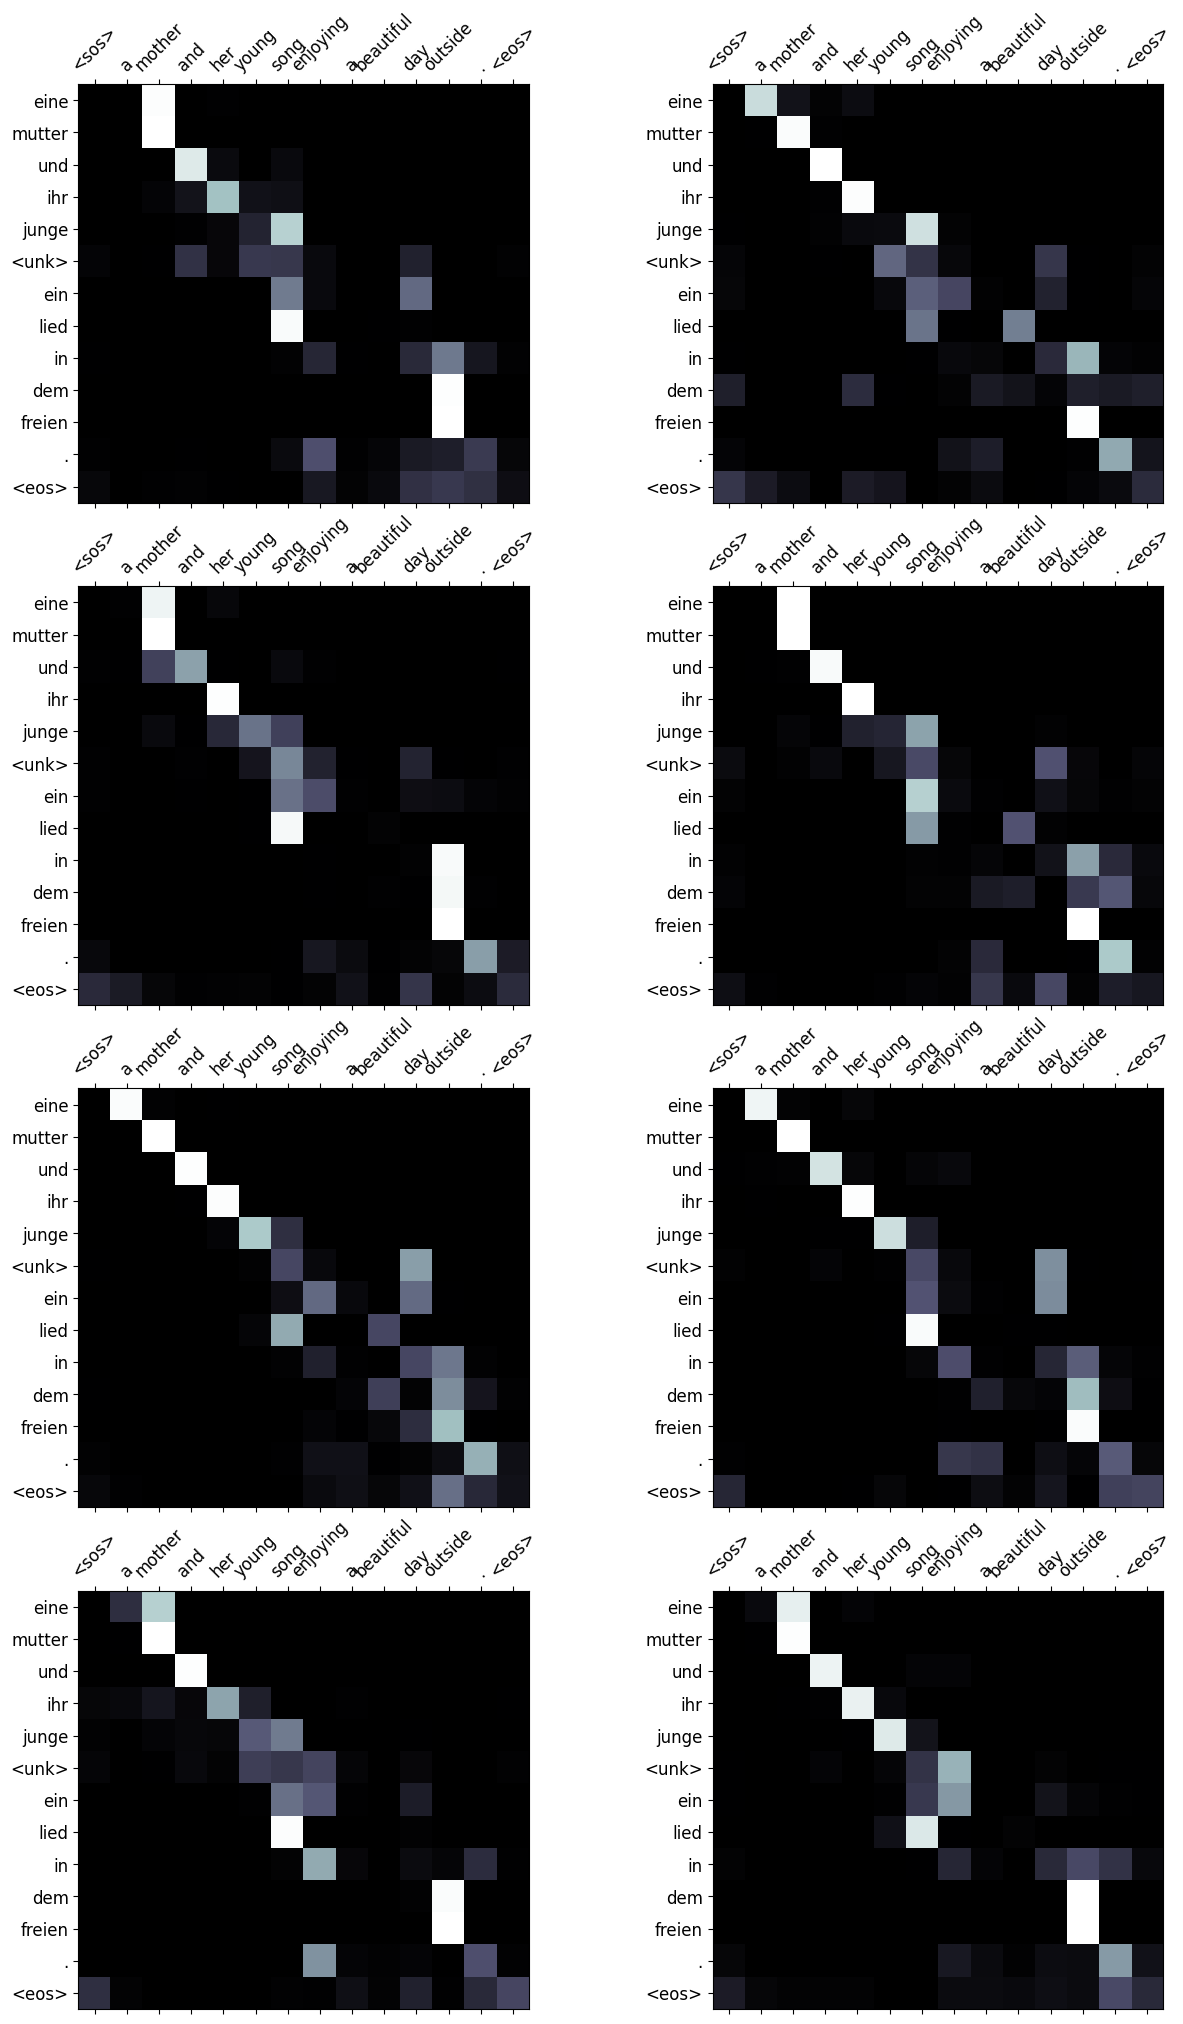

In [35]:
translation, attention = translate_sentence(src, SRC, TRG, model, device)
display_attention(src, translation, attention)
